In [93]:
import pandas as pd
import numpy as np

data = pd.read_csv("Weather_Dataset.csv")
df = pd.DataFrame(data)

cities = ["Mumbai", "Delhi", "Gurugoan", "Kurukshetra", "Gaziabad", "Karnal", "Pehwa", "Jhansa"]
df["City"] = np.random.choice(cities, size=len(df), p=[0.15, 0.20, 0.10, 0.15, 0.10, 0.10, 0.05, 0.15])

#mean temperature
mean_temp = df.groupby("City")["Temp_C"].mean()
# print(mean_temp)

#hottest and coldest cities
hot_city = mean_temp.idxmax()
hot_temp = mean_temp[hot_city]

cold_city = mean_temp.idxmin()
cold_temp = mean_temp[cold_city]

print(f"Hottest City : {hot_city} - {hot_temp:.2f}C " )
print(f"Coldest City : {cold_city} - {cold_temp:.2f}C ")


#count of Rain Showers days and Clear days
weather_count = df.groupby("Weather").count()
rainy_days_count = df["Weather"].str.contains("Rain").sum()
sunny_days_count = df["Weather"].str.contains("Clear").sum()

print(f"\nTotal Rainy Days: {rainy_days_count}")
print(f"Total Sunny/Clear Days: {sunny_days_count}")

Hottest City : Delhi - 9.10C 
Coldest City : Kurukshetra - 8.35C 

Total Rainy Days: 689
Total Sunny/Clear Days: 3432


/tmp/ipykernel_11416/588933715.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=temp_mean.index, y=temp_mean.values, ax = axes['r_top'], palette = "crest", legend = False)


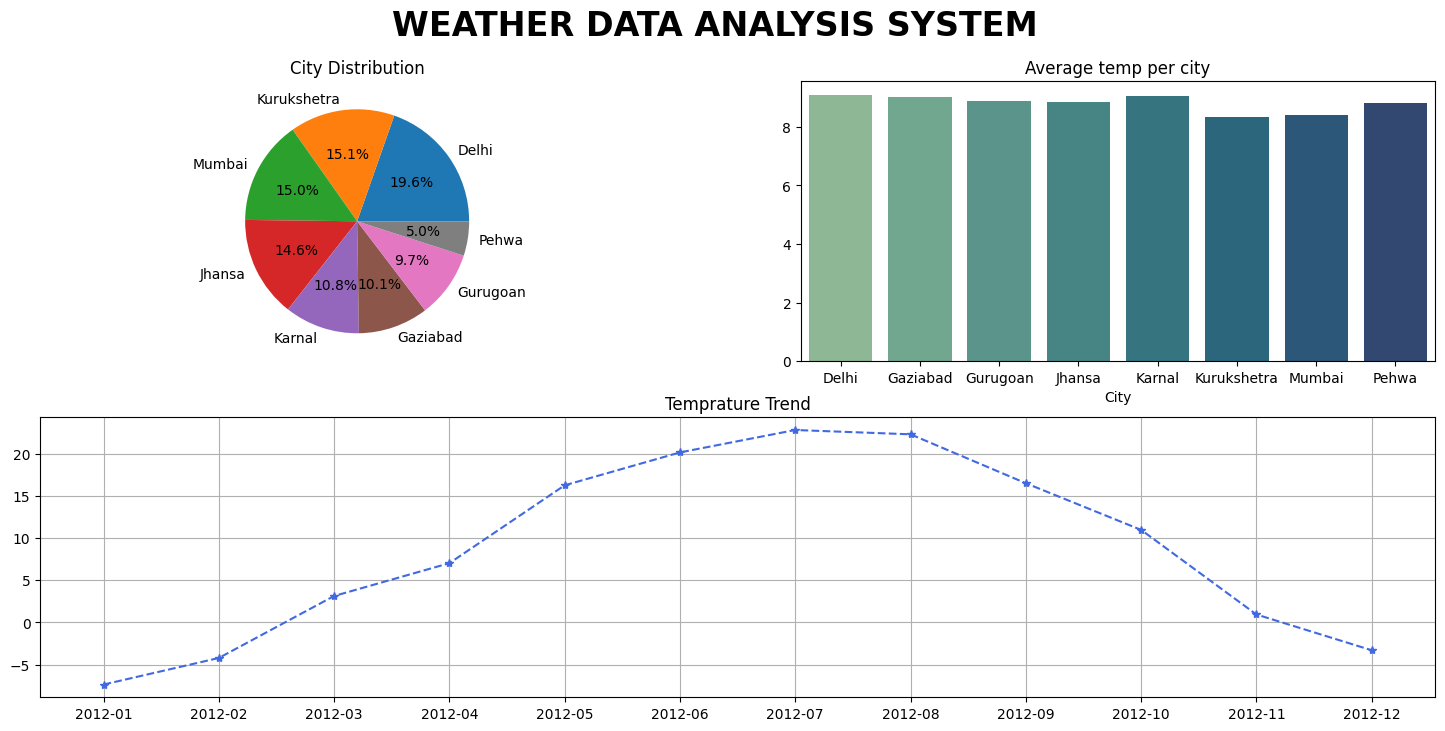

In [103]:
#VISUALIZATION
import matplotlib.pyplot as plt
import seaborn as sns

#top row A and B, bottom row has only C spanning both columns
fig, axes = plt.subplot_mosaic([["l_top", "r_top"],
                                 ['bottom', 'bottom']],
                                 figsize = (18,8))
fig.suptitle("WEATHER DATA ANALYSIS SYSTEM", fontsize = 24, fontweight = 'bold', y = 0.97)

#line graph
df['Date/Time'] = pd.to_datetime(df['Date/Time'])
T_month = df.groupby(df['Date/Time'].dt.to_period('M'))['Temp_C'].mean()
month_temp = T_month.index.astype(str)
axes['bottom'].plot(month_temp, T_month.values, marker = "*", linestyle = "--", color = "royalblue")
axes['bottom'].set_title("Temprature Trend")
axes['bottom'].set_xlable = ("Months")
axes['bottom'].set_ylable = ("Temprature(C)")
axes['bottom'].grid(True)

#pie chart
city_counts = df["City"].value_counts()

axes["l_top"].pie(
    city_counts.values, 
    labels=city_counts.index, 
    autopct="%1.1f%%"
)
axes["l_top"].set_title("City Distribution")


#bar graph
temp_mean = df.groupby("City")["Temp_C"].mean()
sns.barplot(x=temp_mean.index, y=temp_mean.values, ax = axes['r_top'], palette = "crest", legend = False)
# axes['r_top'].bar(x=temp_mean.index , y=temp_mean.values, color = "olive" )
axes['r_top'].set_title("Average temp per city")
axes['r_top'].get_xlable = ('City')
axes['r_top'].get_ylable = ('Temprature(C)')